In [ ]:
Загрузка данных и разбиение

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cirrhosis.csv")

display(df.head())
print(df.info())

X = df.drop(columns=["Status"])
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [ ]:
Препроцессинг данных

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
базовый Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

rf_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_baseline.fit(X_train, y_train)

y_pred = rf_baseline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_test, y_pred, zero_division=0))


Accuracy : 0.8095
Precision: 0.7783
Recall   : 0.8095
F1-score : 0.7880
              precision    recall  f1-score   support

           C       0.79      0.94      0.85        47
          CL       0.00      0.00      0.00         5
           D       0.89      0.75      0.81        32

    accuracy                           0.81        84
   macro avg       0.56      0.56      0.56        84
weighted avg       0.78      0.81      0.79        84



In [ ]:
улучшим, опять же cl класс не угадыввается

In [36]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2 
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)
print(f"Best CV F1: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_best, average="weighted")
f1 = f1_score(y_test, y_pred_best, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV F1: 0.7727
Accuracy : 0.7976
Precision: 0.7640
Recall   : 0.7976
F1-score : 0.7765


In [ ]:
результаты немного ухудшились зато угадывается cv класс
Далее авторская реализация 
самая простая 

In [42]:
class MyDecisionTreeClassifier:
    def __init__(self):
        self.label = None

    def fit(self, X, y):
        self.label = Counter(y).most_common(1)[0][0]
        return self

    def predict(self, X):
        return np.array([self.label] * len(X))


In [ ]:
случайный лес, состоящий из нескольких простых деревьев, 
предсказание осуществляется методом голосования

In [43]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=15):
        self.n_estimators = n_estimators
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.trees = []

        for _ in range(self.n_estimators):
            idx = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[idx]
            y_sample = y[idx]

            tree = MyDecisionTreeClassifier()
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X)

        all_preds = np.array([
            tree.predict(X) for tree in self.trees
        ])

        y_pred = []
        for i in range(X.shape[0]):
            votes = all_preds[:, i]
            y_pred.append(Counter(votes).most_common(1)[0][0])

        return np.array(y_pred)


In [44]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=15):
        self.n_estimators = n_estimators
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.trees = []

        for _ in range(self.n_estimators):
            idx = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[idx]
            y_sample = y[idx]

            tree = MyDecisionTreeClassifier()
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X)

        all_preds = np.array([
            tree.predict(X) for tree in self.trees
        ])

        y_pred = []
        for i in range(X.shape[0]):
            votes = all_preds[:, i]
            y_pred.append(Counter(votes).most_common(1)[0][0])

        return np.array(y_pred)


In [45]:
X_train_proc = best_rf.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_rf.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [46]:

my_rf = MyRandomForestClassifier(n_estimators=15)
my_rf.fit(X_train_proc, y_train)

y_pred_my = my_rf.predict(X_test_proc)

print(f"Accuracy : {accuracy_score(y_test, y_pred_my):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_my, average='weighted', zero_division=0):.4f}")


Accuracy : 0.5595
F1-score : 0.4015


In [ ]:
Результаты низковаты, попробуем улучшить 
реализация дерева с одним разбиением 

In [66]:
class MyDecisionStumpClassifier:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left_label = None
        self.right_label = None
        self.default_label = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.default_label = Counter(y).most_common(1)[0][0]

        n_features = X.shape[1]
        self.feature = np.random.randint(0, n_features)

        values = X[:, self.feature]
        self.threshold = np.median(values)

        left_idx = values <= self.threshold
        right_idx = values > self.threshold

        if left_idx.sum() == 0 or right_idx.sum() == 0:
            self.left_label = self.default_label
            self.right_label = self.default_label
            return self

        self.left_label = Counter(y[left_idx]).most_common(1)[0][0]
        self.right_label = Counter(y[right_idx]).most_common(1)[0][0]

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = []

        for x in X:
            if x[self.feature] <= self.threshold:
                preds.append(self.left_label)
            else:
                preds.append(self.right_label)

        return np.array(preds)


In [ ]:
несколько моделей обученных на бутстреп-выборках
предсказание голосованием

In [67]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.trees = []

        for _ in range(self.n_estimators):
            idx = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[idx]
            y_sample = y[idx]

            tree = MyDecisionStumpClassifier()
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X)

        all_preds = np.array([
            tree.predict(X) for tree in self.trees
        ])

        y_pred = []
        for i in range(X.shape[0]):
            y_pred.append(
                Counter(all_preds[:, i]).most_common(1)[0][0]
            )

        return np.array(y_pred)


In [68]:
X_train_proc = best_rf.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_rf.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [75]:
my_rf_improved = MyRandomForestClassifier(n_estimators=50)
my_rf_improved.fit(X_train_proc, y_train)

y_pred_my_improved = my_rf_improved.predict(X_test_proc)

print(f"Accuracy : {accuracy_score(y_test, y_pred_my_improved):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_my_improved, average='weighted', zero_division=0):.4f}")


Accuracy : 0.6071
F1-score : 0.4988


In [ ]:
стало лучше
Далее сравнение

,Model,F1-score
0,Random Forest базовый,0.787967
1,Random Forest базовый улучшенный,0.776517
2,My Random Forest,0.401490
3,My Random Forest улучшенный,0.498792


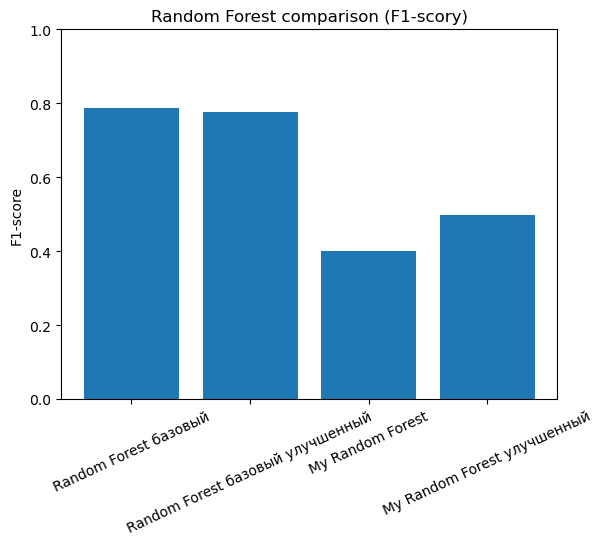

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
results_rf = pd.DataFrame({
    "Model": [
        "Random Forest базовый",
        "Random Forest базовый улучшенный",
        "My Random Forest",
        "My Random Forest улучшенный"
    ],
    "F1-score": [
        f1_score(y_test, y_pred, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_best, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_my, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_my_improved, average="weighted", zero_division=0)
    ]
})

display(results_rf)

plt.figure()
plt.bar(results_rf["Model"], results_rf["F1-score"])
plt.title("Random Forest comparison (F1-scorу)")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()


In [ ]:
Регрессия
загрузка и разбиение

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy import sparse


In [91]:
df = pd.read_csv("mobile.csv") 
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Shapes:
X_train: (668, 9)
X_test : (168, 9)
y_train: (668,)
y_test : (168,)


In [ ]:
препроцесинг

In [92]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
базовая модель

In [94]:
rf_reg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_estimators=100
    ))
])

rf_reg_baseline.fit(X_train, y_train)

y_pred_base = rf_reg_baseline.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_base):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_base):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_base):.4f}")


MAE: 3312.96
MSE: 296406440.24
R2 : 0.8725


In [ ]:
неплохо, попробуем улучшить

In [97]:
from sklearn.model_selection import GridSearchCV

rf_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_reg_grid = GridSearchCV(
    rf_reg_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)
rf_reg_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_reg_grid.best_params_)
print(f"Best CV MAE: {-rf_reg_grid.best_score_:.2f}")

best_rf_reg = rf_reg_grid.best_estimator_

y_pred_best = best_rf_reg.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_best):.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV MAE: 5903.24
MAE: 3379.67
MSE: 322769596.66
R2 : 0.8612


In [ ]:
Далее своя простая реализация

In [109]:
class MyDecisionTreeRegressor:
    def __init__(self):
        self.value = None

    def fit(self, X, y):
        self.value = np.mean(y)
        return self

    def predict(self, X):
        return np.full(len(X), self.value)


In [110]:
class MyRandomForestRegressor:
    def __init__(self, n_estimators=30):
        self.n_estimators = n_estimators
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.trees = []

        for _ in range(self.n_estimators):
            idx = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[idx]
            y_sample = y[idx]

            tree = MyDecisionTreeRegressor()
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = np.array([tree.predict(X) for tree in self.trees])
        return preds.mean(axis=0)


In [111]:
X_train_proc = best_rf_reg.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_rf_reg.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [112]:
my_rf_reg = MyRandomForestRegressor(n_estimators=30)
my_rf_reg.fit(X_train_proc, y_train)

y_pred_my = my_rf_reg.predict(X_test_proc)

print(f"MAE: {mean_absolute_error(y_test, y_pred_my):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_my):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_my):.4f}")


MAE: 20283.96
MSE: 2325943799.33
R2 : -0.0004


In [ ]:
Результат не очень, надо улучшать

In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
построим рекурсивное дерево, ищущее разбиение, уменьшающее mse
также есть ограничения по глубине и размеру

In [123]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=8, min_samples_split=10, max_features="sqrt",
                 n_thresholds=20, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds
        self.random_state = random_state

        self.feature_ = None
        self.threshold_ = None
        self.left_ = None
        self.right_ = None
        self.value_ = None

        self._rng = np.random.default_rng(random_state)

    def _mse(self, y):
        if len(y) == 0:
            return 0.0
        m = np.mean(y)
        return np.mean((y - m) ** 2)

    def _num_features_to_try(self, n_features):
        if self.max_features is None:
            return n_features
        if isinstance(self.max_features, int):
            return max(1, min(n_features, self.max_features))
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        if self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        return max(1, int(np.sqrt(n_features)))

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_mse = self._mse(y)

        k = self._num_features_to_try(n_features)
        feat_idx = self._rng.choice(n_features, size=k, replace=False)

        best_score = parent_mse
        best_feature, best_threshold = None, None

        for f in feat_idx:
            col = X[:, f]
            
            qs = np.linspace(0.05, 0.95, self.n_thresholds)
            thresholds = np.unique(np.quantile(col, qs))

            for t in thresholds:
                left_mask = col <= t
                right_mask = ~left_mask

                n_l = np.sum(left_mask)
                n_r = np.sum(right_mask)

                if n_l == 0 or n_r == 0:
                    continue

                mse_left = self._mse(y[left_mask])
                mse_right = self._mse(y[right_mask])

                score = (n_l / n_samples) * mse_left + (n_r / n_samples) * mse_right

                if score < best_score:
                    best_score = score
                    best_feature = f
                    best_threshold = t

        return best_feature, best_threshold, best_score

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            self.value_ = float(np.mean(y))
            return

        f, t, best_score = self._best_split(X, y)

        if f is None:
            self.value_ = float(np.mean(y))
            return

        col = X[:, f]
        left_mask = col <= t
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            self.value_ = float(np.mean(y))
            return

        self.feature_ = f
        self.threshold_ = t

        self.left_ = MyDecisionTreeRegressor(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            max_features=self.max_features,
            n_thresholds=self.n_thresholds,
            random_state=int(self._rng.integers(0, 1_000_000_000))
        )
        self.right_ = MyDecisionTreeRegressor(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            max_features=self.max_features,
            n_thresholds=self.n_thresholds,
            random_state=int(self._rng.integers(0, 1_000_000_000))
        )

        self.left_._build(X[left_mask], y[left_mask], depth + 1)
        self.right_._build(X[right_mask], y[right_mask], depth + 1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self._build(X, y, depth=0)
        return self

    def _predict_one(self, x):
        if self.value_ is not None and self.feature_ is None:
            return self.value_
        if self.feature_ is None:
            return self.value_ if self.value_ is not None else 0.0

        if x[self.feature_] <= self.threshold_:
            return self.left_._predict_one(x)
        else:
            return self.right_._predict_one(x)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X], dtype=float)


In [ ]:
обучаем деревья на бустреп выборках,
на каждом дереве случайное подмножество признаков,
предсказанием будетсреднее по деревьям

In [124]:
class MyRandomForestRegressor:
    def __init__(self, n_estimators=100, max_depth=8, min_samples_split=10,
                 max_features="sqrt", n_thresholds=20, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds
        self.random_state = random_state

        self.trees_ = []
        self._rng = np.random.default_rng(random_state)

    def _bootstrap(self, X, y):
        n = X.shape[0]
        idx = self._rng.integers(0, n, size=n)
        return X[idx], y[idx]

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.trees_ = []

        for _ in range(self.n_estimators):
            Xb, yb = self._bootstrap(X, y)

            tree = MyDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features,
                n_thresholds=self.n_thresholds,
                random_state=int(self._rng.integers(0, 1_000_000_000))
            )
            tree.fit(Xb, yb)
            self.trees_.append(tree)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = np.array([t.predict(X) for t in self.trees_], dtype=float)
        return preds.mean(axis=0)


In [125]:
my_rf_full = MyRandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=5,
    max_features="sqrt",
    n_thresholds=25,
    random_state=42
)

my_rf_full.fit(X_train_proc, y_train)
y_pred_my_full = my_rf_full.predict(X_test_proc)

print(f"MAE: {mean_absolute_error(y_test, y_pred_my_full):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_my_full):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_my_full):.4f}")


MAE: 9497.58
MSE: 1049648450.62
R2 : 0.5485


In [ ]:
результат значительно улучшился
Далее сравнение

,Model,R2
0,Random Forest базовый,0.872512
1,"Random Forest базовый, улучшенный",0.861173
2,My Random Forest,-0.000418
3,My Random Forest улучшенный,0.548533


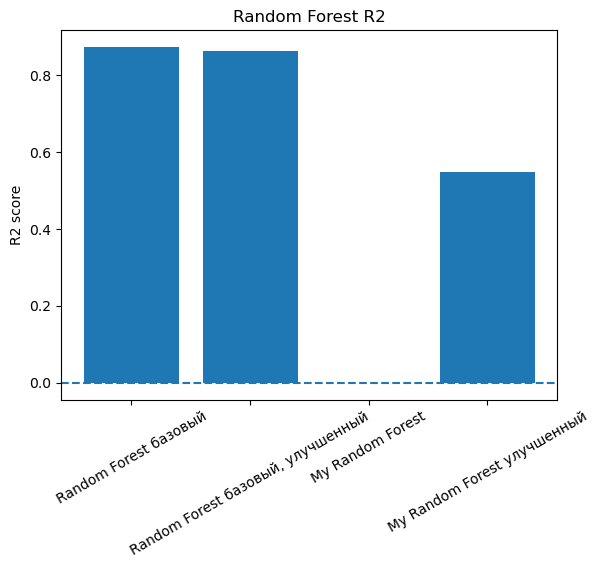

In [129]:
results_reg = pd.DataFrame({
    "Model": [
        "Random Forest базовый",
        "Random Forest базовый, улучшенный",
        "My Random Forest",
        "My Random Forest улучшенный"
    ],
    "R2": [
        r2_score(y_test, y_pred_base),
        r2_score(y_test, y_pred_best),
        r2_score(y_test, y_pred_my),
        r2_score(y_test, y_pred_my_full)
    ]
})

display(results_reg)

plt.figure()
plt.bar(results_reg["Model"], results_reg["R2"])
plt.title("Random Forest R2")
plt.ylabel("R2 score")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=30)
plt.show()
